In [1]:
1+2

3

In [27]:
data = [
    ("i am a student", "je suis un etudiant"),
    ("how are you", "comment allez vous"),
    ("i love machine learning", "j aime apprentissage automatique"),
    ("good morning", "bonjour"),
    ("thank you", "merci"),
    ("see you later", "a plus tard"),
    ("what is your name", "quel est votre nom"),
    ("where are you going", "ou allez vous"),
    ("i like coffee", "j aime le cafe"),
    ("welcome", "bienvenue")
]

In [28]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    TextVectorization,
    Embedding,
    LSTM,
    Dense,
    LayerNormalization,
    MultiHeadAttention,
    Dropout
)


In [8]:
english_sentences = [x[0] for x in data]
french_sentences = ["start " + x[1] + " end" for x in data]


In [9]:
# Tokenization

vocab_size = 1000  # Keep a maximum of 1000 unique words in vocabulary
sequence_length = 20  # Maximum length of each sentence

# tokenize English sentences
source_vectorization = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length
)
source_vectorization.adapt(english_sentences)

# tokenize French sentences
target_vectorization = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length
)
target_vectorization.adapt(french_sentences)


E0000 00:00:1780908918.582395    9486 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [29]:
vocab_size = 1000 # Keep a maximum of 1000 unique words in vocabulary

sequence_length = 20 # Maximum length of each sentence


# tokenize English sentences
source_vectorization = TextVectorization(
    max_tokens = vocab_size,
    output_mode = "int",
    output_sequence_length = sequence_length
)


# tokenize French sentences
target_vectorization = TextVectorization(
    max_tokens = vocab_size,
    output_mode = "int",
    output_sequence_length = sequence_length
)


# This is where learning happens. (Adapt the tokenizers to the data)

source_vectorization.adapt(
    english_sentences
)

target_vectorization.adapt(
    french_sentences
)

In [30]:
# Convert Text Into Numbers
encoder_inputs = source_vectorization(english_sentences)

target_tokens = target_vectorization(french_sentences)


In [31]:
# Prepare decoder input & output
decoder_inputs = target_tokens[:, :-1]
decoder_targets = target_tokens[:, 1:]


In [16]:
!pip install tensorflow


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [32]:
# Positional Encoding

class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim):
        super().__init__()
        self.token_embeddings = layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim
        )
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=embed_dim
        )

    def call(self, inputs):
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        positions = tf.expand_dims(positions, 0)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions


In [33]:
import numpy as np

In [40]:
# + Encoder Block

# Create a custom Encoder Layer
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads):
        super().__init__()
        self.attention = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )
        self.dense_proj = tf.keras.Sequential([
            Dense(dense_dim, activation="relu"),
            Dense(embed_dim)
        ])
        self.layernorm_1 = LayerNormalization()
        self.layernorm_2 = LayerNormalization()

    def call(self, inputs):
        attention_output = self.attention(inputs, inputs)
        x = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(x)
        return self.layernorm_2(x + proj_output)


In [44]:
# Decoder Block

class TransformerDecoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads):
        super().__init__()
        self.self_attention = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )
        self.cross_attention = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )
        self.ffn = tf.keras.Sequential([
            Dense(dense_dim, activation="relu"),
            Dense(embed_dim)
        ])
        self.layernorm1 = LayerNormalization()
        self.layernorm2 = LayerNormalization()
        self.layernorm3 = LayerNormalization()

    def call(self, inputs, encoder_outputs):
        attention_output = self.self_attention(
            query=inputs,
            value=inputs,
            key=inputs,
            use_causal_mask=True
        )
        out1 = self.layernorm1(inputs + attention_output)
        attention_output2 = self.cross_attention(
            query=out1,
            value=encoder_outputs,
            key=encoder_outputs
        )
        out2 = self.layernorm2(out1 + attention_output2)
        ffn_output = self.ffn(out2)
        return self.layernorm3(out2 + ffn_output)


In [49]:
# Build complete Transformer

embed_dim = 128
dense_dim = 256
num_heads = 4


# Encoder Input Layer

encoder_input = tf.keras.Input(
    shape=(None,),
    dtype="int64"
)

x = PositionalEmbedding(
    sequence_length,
    vocab_size,
    embed_dim
)(encoder_input)


# Encoder Block

encoder_output = TransformerEncoder(
    embed_dim,
    dense_dim,
    num_heads
)(x)


# Decoder Block

decoder_input = tf.keras.Input(
    shape=(None,),
    dtype="int64"
)

x2 = PositionalEmbedding(
    sequence_length,
    vocab_size,
    embed_dim
)(decoder_input)

x3 = TransformerDecoder(
    embed_dim,
    dense_dim,
    num_heads
)(x2, encoder_output)

decoder_output = Dense(
    vocab_size,
    activation="softmax"
)(x3)

# Create model

transformer = Model(
    [encoder_input, decoder_input],
    decoder_output
)

/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/layers/layer.py:1566: UserWarning: Layer 'positional_embedding' looks like it has unbuilt state, but Keras is not able to trace the layer `call()` in order to build it automatically. Possible causes:
1. The `call()` method of your layer may be crashing. Try to `__call__()` the layer eagerly on some test input first to see if it works. E.g. `x = np.random.random((3, 4)); y = layer(x)`
2. If the `call()` method is correct, then you may need to implement the `def build(self, input_shape)` method on your layer. It should create all variables used by the layer (e.g. by calling `layer.build()` on all its children layers).
Exception encountered: '''PositionalEmbedding' object has no attribute 'token_embedding'''
  warnings.warn(
/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'positional_embedding', however the layer does not have a `bui

AttributeError: Exception encountered when calling PositionalEmbedding.call().

[1mCould not automatically infer the output shape / dtype of 'positional_embedding' (of type PositionalEmbedding). Either the `PositionalEmbedding.call()` method is incorrect, or you need to implement the `PositionalEmbedding.compute_output_spec() / compute_output_shape()` method. Error encountered:

'PositionalEmbedding' object has no attribute 'token_embedding'[0m

Arguments received by PositionalEmbedding.call():
  • args=('<KerasTensor shape=(None, None), dtype=int64, sparse=False, ragged=False, name=keras_tensor>',)
  • kwargs=<class 'inspect._empty'>

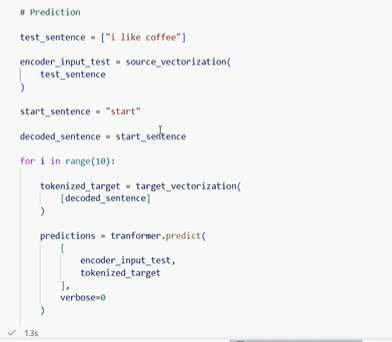